# Gyroscope



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data/imu_xyz.csv')

euler_gt = data[['euler_x', 'euler_y', 'euler_z']].values
gyro = data[['gyroscope_x', 'gyroscope_y', 'gyroscope_z']].values
ts = data['ts'].values
ts = ts/1000 # seconds
ts = ts - ts[0]

In [3]:
gyro_si = gyro * 250 / 32768 * np.pi / 180  # rad/s
print(gyro_si)

[[ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 ...
 [-0.10247045 -0.02301202  0.06096469]
 [-0.10331844 -0.02673439  0.05616185]
 [-0.10354425 -0.0279609   0.05452935]]


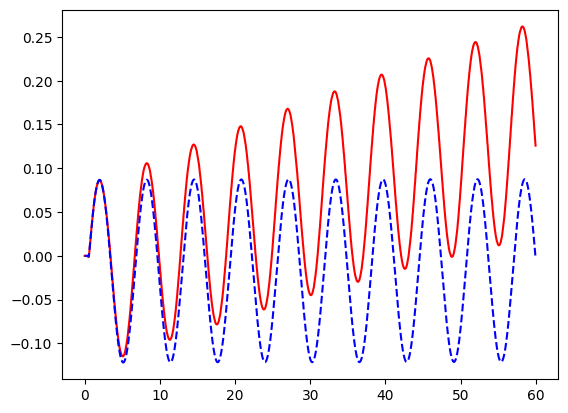

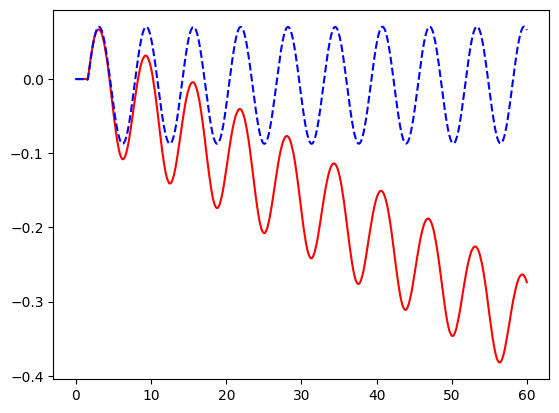

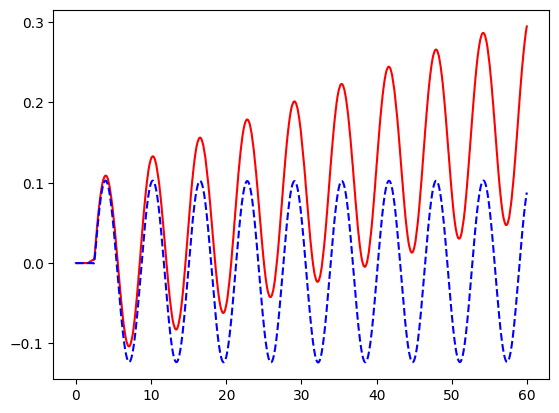

In [4]:
N = gyro_si.shape[0]

euler_est = np.zeros((N, 3))
for i in range(N-1):
    dt = ts[i+1] - ts[i]
    euler_est[i+1] = euler_est[i] + gyro_si[i] * dt


plt.figure()
plt.plot(ts, euler_gt[:, 0] * np.pi/180, 'r',)
plt.plot(ts, euler_est[:, 0], 'b--', )

plt.figure()
plt.plot(ts, euler_gt[:, 1] * np.pi/180, 'r',)
plt.plot(ts, euler_est[:, 1], 'b--', )

plt.figure()
plt.plot(ts, euler_gt[:, 2] * np.pi/180, 'r',)
plt.plot(ts, euler_est[:, 2], 'b--', )



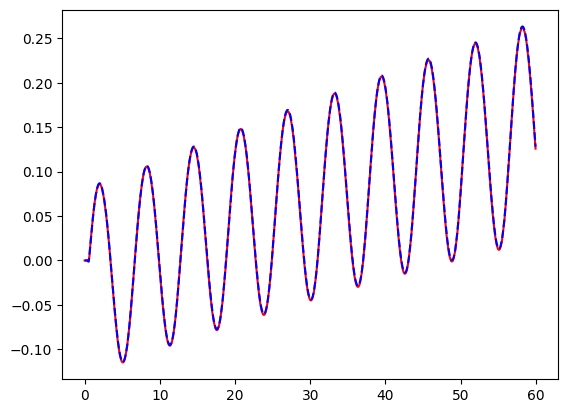

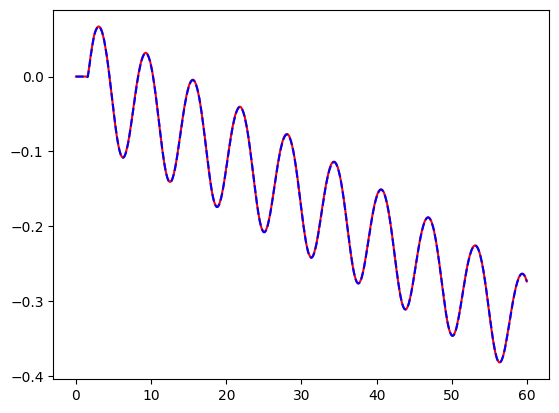

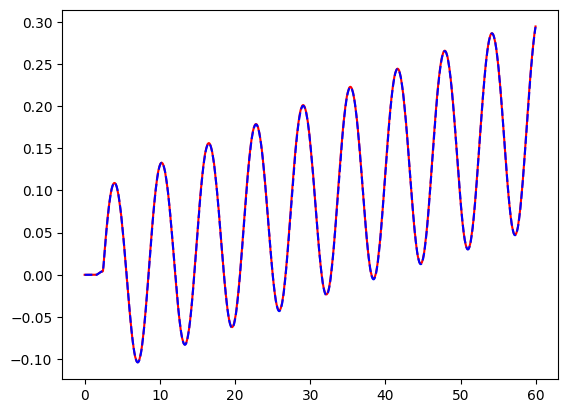

In [5]:
def get_skew(w):
    skew = np.array([[0, -w[2], w[1]],
                        [w[2], 0, -w[0]],
                        [-w[1], w[0], 0]])
    return skew


def get_dR(omega, dt):
        w = omega * dt
        skew = get_skew(w)
        ww = np.dot(w, w)
        ww_sqrt = np.sqrt(ww)
        if ww_sqrt == 0:
            dR = np.eye(3) 
        else:
            dR = np.eye(3)
            dR += np.sin(ww_sqrt) / ww_sqrt * skew 
            dR += (1 - np.cos(ww_sqrt)) / ww * np.matmul(skew, skew)
        return dR

def rotm2eul(rotm):
    return np.array([np.arctan2(rotm[2, 1], rotm[2, 2]),
                        np.arctan2(-rotm[2, 0], np.sqrt(rotm[2, 1]**2 + rotm[2, 2]**2)),
                        np.arctan2(rotm[1, 0], rotm[0, 0])])


N = gyro_si.shape[0]
euler_est = np.zeros((N, 3))
R = np.eye(3)

for i in range(N-1):
    dt = ts[i+1] - ts[i]
    omega = gyro_si[i]
    dR = get_dR(omega, dt)
    R = R@dR
    euler_est[i+1] = rotm2eul(R)


plt.figure()
plt.plot(ts, euler_gt[:, 0] * np.pi/180, 'r',)
plt.plot(ts, euler_est[:, 0], 'b--', )

plt.figure()
plt.plot(ts, euler_gt[:, 1] * np.pi/180, 'r',)
plt.plot(ts, euler_est[:, 1], 'b--', )

plt.figure()
plt.plot(ts, euler_gt[:, 2] * np.pi/180, 'r',)
plt.plot(ts, euler_est[:, 2], 'b--', )


